# 📈 Day 3 — Logistic Regression & Classification Metrics

## 📖 Introduction

Many real-world Machine Learning problems do not require predicting numerical values. Instead, the goal is often to determine which category an observation belongs to.

For example:

- Will a customer leave the company?
- Is an email spam or not spam?
- Does a patient have a disease?
- Will a passenger survive the Titanic disaster?

These problems belong to **classification**, one of the most important areas of supervised learning.

In this notebook, we will build our first **classification model** using **Logistic Regression**. Although its name contains the word *Regression*, Logistic Regression is designed to predict categories by estimating the probability that an observation belongs to a particular class.

Using the **Titanic dataset**, we will train a classifier, generate predictions, analyze class probabilities, evaluate performance using multiple classification metrics, and understand why relying on accuracy alone can sometimes lead to misleading conclusions.

By the end of this notebook, we will be able to interpret a confusion matrix, understand precision, recall, F1-score, and AUC-ROC, and recognize how each metric provides a different perspective on model performance.

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- Explain the difference between regression and classification.
- Understand how Logistic Regression predicts probabilities.
- Train a Logistic Regression classifier using Scikit-learn.
- Generate class predictions and class probabilities.
- Interpret a Confusion Matrix.
- Evaluate a classifier using Accuracy, Precision, Recall, F1-score, and AUC-ROC.
- Explain why accuracy alone is not always a reliable evaluation metric.

## 📑 Table of Contents

1. 📖 Introduction

2. 🎯 Learning Objectives

3. 🛠 Libraries Used

4. 📂 Meet the Dataset

5. 🧹 Data Preprocessing

6. 🎯 Features and Target

7. ✂️ Train-Test Split

8. 🔄 Recap: Supervised Learning

9. 🧠 From Regression to Classification

10. 📈 What is Logistic Regression?

11. 🔢 The Sigmoid Function

12. ⚙️ Training the Logistic Regression Model

13. 📊 Class Predictions vs. Class Probabilities

14. 📉 Why Accuracy Alone Is Not Enough

15. 🔍 Understanding the Confusion Matrix

16. 📏 Precision, Recall, and F1-Score

17. 📈 ROC Curve and AUC-ROC

18. 🖥️ Hands-On Lab: Building a Logistic Regression Classifier

19. 🚀 GitHub Submission

20. 💭 Reflection

21. 🔑 Key Takeaways

22. ✅ Conclusion

## 🛠 Libraries Used

This notebook uses the following Python libraries:

- **Pandas** for loading and manipulating the dataset.
- **NumPy** for numerical computations.
- **Matplotlib** for visualizations.
- **Scikit-learn** for building and evaluating the Logistic Regression model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

These libraries provide everything needed to prepare the dataset, train a classification model, generate predictions, and evaluate its performance using a variety of classification metrics.

## 📂 Meet the Dataset

To demonstrate Logistic Regression, we will use the **Titanic** dataset.

The dataset contains information about passengers aboard the Titanic, including demographic details and travel-related features such as passenger class, age, fare, family size, and sex.

Our objective is to predict whether a passenger **survived** or **did not survive** the disaster.

Unlike the previous notebook, where the target variable was continuous, the target variable in this dataset contains only two possible outcomes:

- **1 → Survived**
- **0 → Did Not Survive**

Since the goal is to predict a category rather than a numerical value, this is a **binary classification problem**.

In [2]:
df = pd.read_csv("Titanic_Clean.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Unknown,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,Unknown,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Unknown,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,Unknown,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,Unknown,S


In [3]:
print(df.shape)

(418, 12)


### 📌 Interpretation

The dataset consists of passenger records, where each row represents one individual and each column describes one of their characteristics.

The target variable is **Survived**, indicating whether the passenger survived the disaster.

Understanding the dataset structure before building a model helps identify the available features and the prediction target.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         418 non-null    float64
 10  Cabin        418 non-null    str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,1100.500000,0.363636,2.265550,29.399522,0.447368,0.392344,35.560845
std,120.810458,0.481622,0.841838,12.992298,0.896760,0.981429,55.856972
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,23.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,25.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,36.375000,1.000000,0.000000,31.471875
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

### 📌 Interpretation

The dataset contains clean numerical and categorical features with no missing values, making it ready for Machine Learning.

Exploring the dataset before training allows us to understand the available information and verify that the data is suitable for classification.

## 🧹 Data Preprocessing

Before training a machine learning model, all input features must be numerical. However, the Titanic dataset contains several categorical and text-based columns that cannot be used directly by Logistic Regression.

To prepare the data:
- Remove columns that are not useful for prediction.
- Encode categorical variables into numerical values.
- Keep only features suitable for model training.

In [7]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [8]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Pclass    418 non-null    int64  
 2   Sex       418 non-null    int64  
 3   Age       418 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Fare      418 non-null    float64
 7   Embarked  418 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 26.3 KB


## 🔄 Recap: From Supervised Learning to Classification

In the previous notebook, we built our first supervised learning model using **Linear Regression**, where the objective was to predict a continuous numerical value.

The workflow followed the standard Scikit-learn pipeline:

```
Dataset
   ↓
Train-Test Split
   ↓
Train the Model
   ↓
Generate Predictions
   ↓
Evaluate Performance
```

Although today's workflow remains exactly the same, one important difference changes everything:

- **Yesterday**, the model predicted a numerical value.
- **Today**, the model predicts a category.

This shift introduces a different type of Machine Learning problem known as **classification**.

# 🆚 From Regression to Classification

Both **Regression** and **Classification** belong to **Supervised Learning**, meaning that the model learns from labeled examples.

The difference lies entirely in the type of target variable being predicted.

| Regression | Classification |
|------------|----------------|
| Predicts continuous values | Predicts categories |
| Output is a number | Output is a class |
| Example: House Price | Example: Titanic Survival |
| Example: Temperature | Example: Spam Detection |
| Metrics: MAE, RMSE, R² | Metrics: Accuracy, Precision, Recall, F1, AUC |

Because the Titanic dataset asks whether a passenger **survived or not**, our target variable contains only two possible classes.

Therefore, this is a **binary classification problem**, making Logistic Regression an appropriate algorithm.

## 🤔 Why Can't We Use Linear Regression?

A natural question might be:

> Why don't we simply use Linear Regression?

Linear Regression predicts any continuous numerical value.

For example, it may produce predictions such as:

- 1.37
- -0.42
- 2.15

These values make sense for predicting house prices or temperatures, but they do not make sense when the only valid answers are:

- Survived (1)
- Did Not Survive (0)

Classification models solve this problem by predicting **probabilities** instead of unrestricted numerical values.

# 📈 What is Logistic Regression?

Despite its name, **Logistic Regression** is not a regression algorithm.

It is one of the most widely used **classification algorithms**, designed to estimate the probability that an observation belongs to a particular class.

Instead of predicting any numerical value, Logistic Regression always produces a probability between **0 and 1**.

For example:

- 0.92 → 92% probability of survival.
- 0.74 → 74% probability of survival.
- 0.18 → 18% probability of survival.

These probabilities are then converted into class labels using a decision threshold, typically **0.5**.

## 🧮 How Does Logistic Regression Work?

Logistic Regression follows two consecutive steps.

### Step 1 — Calculate a Weighted Sum

Just like Linear Regression, the model first computes a weighted combination of the input features:

$$
z=w_1x_1+w_2x_2+\cdots+w_nx_n+b
$$

This equation should look familiar.

It is exactly the same dot-product equation introduced in **Week 2 (Linear Algebra)** and used again in **Day 2 (Linear Regression)**.

At this stage, however, the output can be **any real number**, including negative or very large values.

Since probabilities must always lie between **0 and 1**, another step is required.

## 📉 Step 2 — Apply the Sigmoid Function

The weighted sum is passed through the **Sigmoid Function**, which transforms any real number into a probability.

The sigmoid equation is

$$
P=\frac{1}{1+e^{-z}}
$$

where:

- **z** is the weighted sum.
- **P** is the predicted probability.

Regardless of how large or small the weighted sum becomes, the sigmoid function always produces an output between **0 and 1**.

This property makes Logistic Regression suitable for binary classification problems.

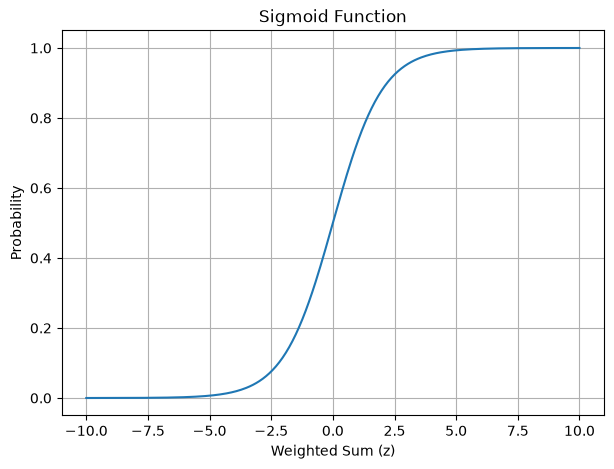

In [10]:
x = np.linspace(-10, 10, 300)

sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(7,5))

plt.plot(x, sigmoid)

plt.title("Sigmoid Function")

plt.xlabel("Weighted Sum (z)")

plt.ylabel("Probability")

plt.grid(True)

plt.show()

### 📌 Interpretation

The sigmoid curve converts any numerical value into a probability.

- Large negative values become probabilities close to **0**.
- Large positive values become probabilities close to **1**.
- A weighted sum equal to **0** corresponds to a probability of **0.5**.

Instead of predicting arbitrary numbers, Logistic Regression predicts how likely an observation belongs to the positive class.

## 🎯 Decision Threshold

Predicting probabilities is only the first step.

To make a final decision, Logistic Regression compares the predicted probability against a predefined threshold.

The default threshold in Scikit-learn is **0.5**.

```
Probability ≥ 0.50
        ↓
Predict Class 1

Probability < 0.50
        ↓
Predict Class 0
```

For example:

| Predicted Probability | Final Prediction |
|----------------------:|----------------:|
| 0.91 | Survived |
| 0.73 | Survived |
| 0.48 | Did Not Survive |
| 0.12 | Did Not Survive |

Although **0.5** is commonly used, this threshold can be adjusted depending on the problem. In medical diagnosis, for example, a lower threshold may be chosen to reduce the risk of missing true positive cases.

# 🎯 Features and Target

Like every supervised learning problem, Logistic Regression learns the relationship between a set of input features (**X**) and a target variable (**y**).

- **Features (X):** The information the model uses to make predictions.
- **Target (y):** The correct answer the model is trying to learn.

For the Titanic dataset:

- The input features describe each passenger, such as age, fare, passenger class, and sex.
- The target variable is **Survived**, indicating whether the passenger survived the disaster.

Our objective is to train a model that predicts the value of **Survived** for passengers it has never seen before.

In [11]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (418, 7)
Target shape: (418,)


### 📌 Interpretation

The dataset has now been divided into **features (X)** and the **target (y)**.

The model will use the information contained in the feature columns to learn patterns associated with passenger survival, while the **Survived** column serves as the correct answer during training.

# ✂️ Train-Test Split

Before training any Machine Learning model, it is essential to separate the dataset into two independent subsets.

- **Training Set:** Used to teach the model the relationship between the features and the target.
- **Testing Set:** Reserved for evaluating the model on data it has never seen before.

Evaluating a model on unseen data provides a realistic estimate of how well it will perform in real-world situations.

In this notebook, we will use an **80/20 split**, where:

- **80%** of the data is used for training.
- **20%** is reserved for testing.

A fixed **random_state** is also specified to ensure that the split remains reproducible every time the notebook is executed.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (334, 7)
X_test : (84, 7)
y_train: (334,)
y_test : (84,)


### 📌 Interpretation

The dataset has now been successfully divided into training and testing subsets.

The Logistic Regression model will learn exclusively from the training data, while the testing data will remain completely unseen until evaluation.

This separation prevents data leakage and provides an unbiased assessment of the model's ability to generalize to new observations.

## Model Workflow

```text
Titanic Dataset
        │
        ▼
Data Preprocessing
        │
        ▼
Features & Target
        │
        ▼
Train-Test Split
        │
        ▼
Logistic Regression
        │
        ▼
Predictions
        │
        ▼
Model Evaluation
```

# 🚀 Model Training

Now that the dataset has been prepared and divided into training and testing subsets, the Logistic Regression model is ready to learn.

During training, the algorithm analyzes the relationship between the input features and the target variable. Rather than memorizing the training examples, it estimates the coefficients that maximize the probability of making correct classifications.

Once the training process is complete, these learned coefficients are used to predict the class of new, unseen passengers.

## Step 1 — Create the Model

The first step is to instantiate a Logistic Regression model.

At this stage, the model has not learned anything yet. It simply initializes the algorithm with its default settings and prepares it for training.

We specify **max_iter=1000** to ensure that the optimization algorithm has enough iterations to converge successfully.

In [13]:
model = LogisticRegression(max_iter=1000)

The model has now been initialized and is ready to learn from the training data.

## Step 2 — Train the Model

Training is the learning phase of Machine Learning.

During this step, Logistic Regression analyzes the training data and estimates the coefficients that best separate the two classes.

The model learns only from **X_train** and **y_train**, while the testing data remains completely hidden until evaluation.

In [14]:
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### 📌 Interpretation

The training process is now complete.

The Logistic Regression model has learned the relationship between passenger characteristics and survival outcomes using only the training dataset.

These learned patterns will now be used to classify passengers that the model has never encountered before.

# 🔮 Generating Predictions

Once the Logistic Regression model has been trained, it can be used to classify passengers it has never seen before.

The model applies the patterns learned during training to the testing dataset and predicts whether each passenger is likely to survive.

Scikit-learn provides two different prediction methods:

- **`predict()`** returns the predicted class (0 or 1).
- **`predict_proba()`** returns the probability of belonging to each class.

Although both methods are useful, understanding the difference between them is essential because most classification metrics are based on probabilities rather than class labels.

## Step 3 — Generate Class Predictions

The `predict()` method returns the final predicted class for every observation in the testing dataset.

Each prediction is either:

- **0 → Did Not Survive**
- **1 → Survived**

In [15]:
predictions = model.predict(X_test)

predictions[:10]

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])

### 📌 Interpretation

Each value represents the model's final decision for one passenger.

At this stage, the model only provides the predicted class without explaining how confident it is about that prediction.

# 🎯 Predicting Class Probabilities

Classification models do more than simply predict a class.

Before making the final decision, Logistic Regression estimates the probability that each observation belongs to every possible class.

This probability provides valuable information about the model's confidence and allows us to evaluate performance using metrics such as the ROC Curve and AUC.

Instead of asking:

> "Which class?"

we first ask:

> "How likely is each class?"

## Step 4 — Predict Class Probabilities

The `predict_proba()` method returns two probabilities for every passenger:

- Probability of **Class 0 (Did Not Survive)**.
- Probability of **Class 1 (Survived)**.

The probabilities always add up to **1.0**.

In [16]:
probabilities = model.predict_proba(X_test)

probabilities[:10]

array([[0.9727296 , 0.0272704 ],
       [0.04077363, 0.95922637],
       [0.96561622, 0.03438378],
       [0.9787137 , 0.0212863 ],
       [0.06579168, 0.93420832],
       [0.97461854, 0.02538146],
       [0.07718419, 0.92281581],
       [0.97354514, 0.02645486],
       [0.06705117, 0.93294883],
       [0.97802373, 0.02197627]])

### 📌 Interpretation

Each row contains two probability values.

For example,

```
[0.91, 0.09]
```

means there is:

- 91% probability that the passenger did **not survive**.
- 9% probability that the passenger **survived**.

Likewise,

```
[0.18, 0.82]
```

indicates an 82% probability of survival.

The class with the higher probability becomes the model's final prediction.

## 📊 Comparing Predictions with Actual Values

Before evaluating the model using classification metrics, it is useful to compare the predicted classes with the actual outcomes.

This provides an initial qualitative assessment of the model's performance.

In [17]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
321,0,0
324,1,1
388,0,0
56,0,0
153,1,1
30,0,0
72,1,1
82,0,0
258,1,1
416,0,0


### 📌 Interpretation

The comparison table shows whether the model correctly classified each passenger.

Rows where the predicted value matches the actual value represent correct classifications, while mismatches correspond to classification errors.

These errors will be analyzed more systematically using the evaluation metrics in the following sections.

# 🎯 Model Evaluation

Once predictions have been generated, the next step is to evaluate how well the classifier performs.

Unlike regression, where prediction errors are measured using numerical distances, classification models are evaluated by comparing the predicted classes with the true classes.

Different evaluation metrics capture different aspects of performance.

In the following sections, we will explore why relying on **Accuracy** alone is often insufficient and introduce additional metrics that provide a more complete assessment of classification models.

## 📊 Accuracy

Accuracy is the simplest and most commonly reported classification metric.

It measures the proportion of correctly classified observations out of all predictions.

Mathematically,

$$
Accuracy=\frac{Correct\ Predictions}{Total\ Predictions}
$$

Although accuracy is easy to understand, it does not always reflect the true quality of a classifier, especially when the dataset is imbalanced.

### 📌 Interpretation

The accuracy score indicates the percentage of passengers that were correctly classified by the model.

While a high accuracy may seem encouraging, it should never be interpreted in isolation.

To fully understand the model's performance, we must examine the types of errors it makes, which is why the confusion matrix and additional classification metrics are essential.

# ⚠️ Why Accuracy Alone Can Be Misleading

Accuracy is often the first metric people look at when evaluating a classification model because it is simple and easy to understand.

However, accuracy alone does not tell the whole story.

Imagine a dataset where **95% of customers stay with a company** and only **5% leave**.

If a model predicts that **every customer will stay**, it will achieve an accuracy of **95%**, despite failing to identify a single customer who actually leaves.

Although the accuracy appears excellent, the model provides little practical value.

This illustrates why classification problems require additional evaluation metrics that consider not only the number of correct predictions but also the types of mistakes the model makes.

For this reason, we analyze the **Confusion Matrix**, **Precision**, **Recall**, **F1-score**, and **ROC-AUC**, each of which highlights a different aspect of model performance.

# 📊 The Confusion Matrix

The **Confusion Matrix** provides a detailed summary of a classifier's predictions by comparing the predicted labels with the true labels.

Rather than reporting a single score, it categorizes every prediction into one of four possible outcomes.

This makes it the foundation of nearly every classification metric.

The four possible outcomes are:

| Actual | Predicted | Outcome |
|---------|-----------|---------|
| Positive | Positive | True Positive (TP) |
| Positive | Negative | False Negative (FN) |
| Negative | Positive | False Positive (FP) |
| Negative | Negative | True Negative (TN) |

### 📌 Understanding Each Outcome

- **True Positive (TP):** The passenger survived, and the model correctly predicted survival.

- **True Negative (TN):** The passenger did not survive, and the model correctly predicted non-survival.

- **False Positive (FP):** The model predicted survival, but the passenger actually did not survive.

- **False Negative (FN):** The passenger survived, but the model predicted that they did not.

Among these, **False Positives** and **False Negatives** represent the model's mistakes.

In [18]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[50  0]
 [ 0 34]]


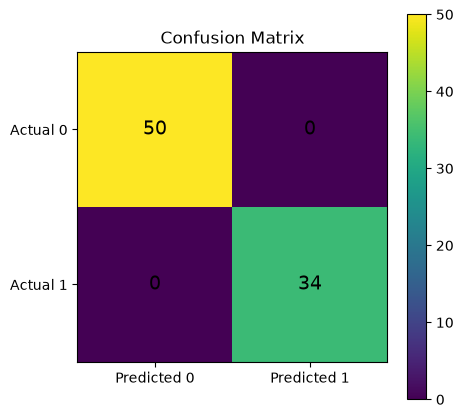

In [19]:
fig, ax = plt.subplots(figsize=(5,5))

im = ax.imshow(cm)

ax.set_xticks([0,1])
ax.set_yticks([0,1])

ax.set_xticklabels(["Predicted 0","Predicted 1"])
ax.set_yticklabels(["Actual 0","Actual 1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center",
                va="center",
                fontsize=14)

plt.title("Confusion Matrix")

plt.colorbar(im)

plt.show()

### 📌 Interpretation

The diagonal cells represent **correct classifications**, while the off-diagonal cells represent **classification errors**.

Ideally, most observations should appear on the diagonal, indicating that the model correctly classified the majority of passengers.

The confusion matrix not only shows how many mistakes the model made but also reveals **which type of mistake occurred**, providing much deeper insight than accuracy alone.

# 📈 Precision, Recall and F1-score

While the confusion matrix summarizes prediction outcomes, it is often useful to convert these counts into numerical evaluation metrics.

The three most commonly used metrics are:

- Precision
- Recall
- F1-score

Each metric focuses on a different aspect of model performance.

In [20]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



## 🎯 Precision

Precision answers the following question:

> **Of all passengers predicted to survive, how many actually survived?**

A high precision means that when the model predicts survival, it is usually correct.

Precision becomes especially important when **false positives are costly**.

## 🎯 Recall

Recall answers a different question:

> **Of all passengers who actually survived, how many did the model successfully identify?**

A high recall means that the model misses very few true survivors.

Recall becomes especially important when **missing positive cases is expensive**, such as disease detection.

## 🎯 F1-score

The F1-score combines Precision and Recall into a single metric.

It is particularly useful when both false positives and false negatives are important.

Instead of favoring one metric over the other, the F1-score measures how well the classifier balances both.

### 📌 Interpretation

The classification report summarizes the model's performance for each class.

Rather than relying on a single metric, it provides a balanced evaluation by considering both correctly classified observations and different types of classification errors.

Together, Precision, Recall, and F1-score provide a much more complete understanding of model performance than Accuracy alone.

# 🎯 Which Metric Matters More for the Titanic Dataset?

The importance of Precision and Recall depends entirely on the problem being solved.

For the Titanic dataset, our objective is to identify passengers who survived.

Missing a survivor (**False Negative**) means incorrectly predicting that someone did not survive when they actually did.

On the other hand, a **False Positive** predicts survival for someone who actually did not survive.

Since this notebook is an educational exercise rather than a life-critical application, both Precision and Recall are important.

However, if the primary objective is to identify as many survivors as possible, **Recall** becomes slightly more important because it minimizes the number of missed survivors.

# 📈 ROC Curve and AUC

While Accuracy, Precision, and Recall evaluate a classifier using a single decision threshold (typically 0.5), they do not show how the model behaves when that threshold changes.

Instead of evaluating the classifier at one threshold, the **Receiver Operating Characteristic (ROC) Curve** measures its performance across **all possible classification thresholds**.

The ROC Curve compares:

- **True Positive Rate (Recall)** on the vertical axis.
- **False Positive Rate** on the horizontal axis.

A classifier that consistently identifies positive cases while minimizing false alarms will produce a curve that stays close to the upper-left corner of the graph.

The **Area Under the ROC Curve (AUC)** summarizes this curve into a single number, making it easier to compare different classifiers.

## 📊 Interpreting AUC

The AUC score ranges from **0.5** to **1.0**.

| AUC Score | Interpretation |
|-----------|----------------|
| 0.50 | Random guessing |
| 0.60 – 0.70 | Poor classifier |
| 0.70 – 0.80 | Acceptable performance |
| 0.80 – 0.90 | Good classifier |
| 0.90 – 1.00 | Excellent classifier |

Generally, a higher AUC indicates that the model is better at distinguishing between the two classes regardless of the chosen decision threshold.

In [21]:
probabilities = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probabilities)

auc = roc_auc_score(y_test, probabilities)

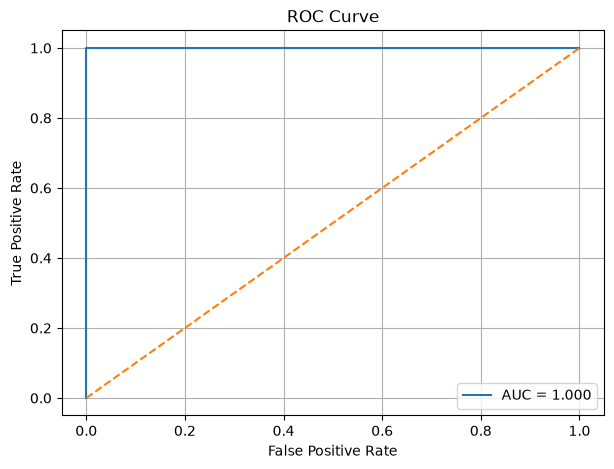

In [22]:
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

### 📌 Interpretation

The ROC curve illustrates the classifier's ability to distinguish between passengers who survived and those who did not across different decision thresholds.

The closer the curve is to the upper-left corner, the better the classifier performs.

The diagonal dashed line represents random guessing. Since our Logistic Regression model produces a curve above this baseline, it demonstrates meaningful predictive capability.

The AUC score summarizes this performance into a single value. A higher AUC indicates that the model is more effective at separating the two classes and is less dependent on a specific decision threshold.

# 🖥️ Hands-on Lab: Building a Classifier

The following steps summarize the complete classification workflow implemented throughout this notebook.

Each task corresponds directly to the official lab requirements.

## Step 1 — Train a Logistic Regression Model

In [23]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## Step 2 — Generate Predictions and the Confusion Matrix

In [24]:
predictions = model.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print(cm)

[[50  0]
 [ 0 34]]


## Step 3 — Evaluate the Model Using Precision, Recall and F1-score

In [25]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



### 📌 Interpretation

The classification report provides a detailed summary of the classifier's performance.

Rather than relying solely on Accuracy, it evaluates how well the model identifies each class by measuring Precision, Recall, and F1-score.

Together, these metrics provide a more comprehensive assessment of classification performance.

## Step 4 — Decide Whether Precision or Recall Matters More

For the Titanic dataset, **Recall** is slightly more important.

The primary objective is to correctly identify as many passengers who survived as possible.

A False Negative means predicting that a passenger did not survive when they actually did.

Therefore, maximizing Recall helps reduce the number of missed survivors.

## Step 5 — Compute and Interpret the AUC-ROC

In [26]:
auc = roc_auc_score(y_test, probabilities)

print(f"AUC Score: {auc:.3f}")

AUC Score: 1.000


### 📌 Interpretation

The AUC score summarizes the classifier's ability to distinguish between survivors and non-survivors across all possible decision thresholds.

A value substantially higher than **0.50** indicates that the classifier has learned meaningful patterns from the data and performs significantly better than random guessing.

## 🚀 GitHub Submission

This notebook has been completed as part of the **AI & Machine Learning Internship – Week 3 (Day 3)**.

The final version, including all code, explanations, visualizations, and interpretations, has been uploaded to my GitHub portfolio as part of my Machine Learning learning journey.

## 💭 Reflection

This notebook introduced my first classification model using Logistic Regression.

Beyond learning how to train a classifier, I realized that evaluating classification models requires much more than simply checking Accuracy. Understanding the Confusion Matrix, Precision, Recall, F1-score, and ROC-AUC showed me that different metrics answer different questions about model performance.

One of the most valuable lessons was recognizing that the importance of a metric depends on the problem itself. In some applications, identifying every positive case is more important than avoiding false alarms, while in others the opposite is true.

This notebook also reinforced the importance of interpreting model outputs rather than only generating predictions, helping me better understand how Machine Learning models make classification decisions.

## 🔑 Key Takeaways

- Logistic Regression is a classification algorithm.

- It predicts probabilities rather than continuous values.

- The Sigmoid function converts weighted sums into probabilities.

- Accuracy alone can be misleading.

- The Confusion Matrix explains prediction errors.

- Precision, Recall, F1-score, and ROC-AUC provide a more complete evaluation.

## ✅ Conclusion

In this notebook, I built my first Logistic Regression classifier using the Titanic dataset.

I explored the complete Machine Learning workflow, beginning with data preparation and train-test splitting, followed by model training, prediction generation, probability estimation, and performance evaluation.

The classifier was assessed using Accuracy, the Confusion Matrix, Precision, Recall, F1-score, and ROC-AUC, demonstrating that no single metric is sufficient to evaluate a classification model.

These concepts establish the foundation for more advanced classification algorithms that will be explored in the following notebook, where multiple models will be trained and compared on the same dataset to understand their strengths and limitations.